In [1]:
%load_ext watermark


In [2]:
import io
import math

from Bio import Phylo as BioPhylo
from IPython.display import display, HTML
from hstrat import _auxiliary_lib as hstrat_aux
import polars as pl
from slugify import slugify
from teeplot import teeplot as tp

from pylib._disable_ax_clip import disable_ax_clip
from pylib._draw_biophylo_vertical import draw_biopyhlo_vertical
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-05-22T05:31:57.282326+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1027-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot: 1.4.2
hstrat : 1.20.11
polars : 1.29.0
Bio    : 1.85

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-17-vanilla-treeviz"
teeplot_subdir


'2025-05-17-vanilla-treeviz'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
url = "https://osf.io/r8skg/download"
tmp_path = f"/tmp/{teeplot_subdir}.pqt"

print(f"Downloading data from {url}")

pl.scan_parquet(
    url,
    low_memory=True,
    retries=5,
).sink_parquet(tmp_path)
print("done!")


done!


In [7]:
df = pl.scan_parquet(
    tmp_path,
    low_memory=True,
    retries=5,
)
schema = df.collect_schema()


In [8]:
fil = (
    df.filter(
        pl.col("trt_hsurf_bits").eq(0),
    )
    .filter(
        pl.col("replicate_uuid").eq(
            pl.col("replicate_uuid").first().over("trt_name"),
        )
    )
    .select(
        pl.exclude([k for k, v in schema.items() if v == pl.String]),
    )
    .collect()
)


## Plot Data


teeplots/2025-05-17-vanilla-treeviz/trt_name=sben1-3x-gneu+viz=draw-biopyhlo-vertical+ext=.pdf
teeplots/2025-05-17-vanilla-treeviz/trt_name=sben1-3x-gneu+viz=draw-biopyhlo-vertical+ext=.png


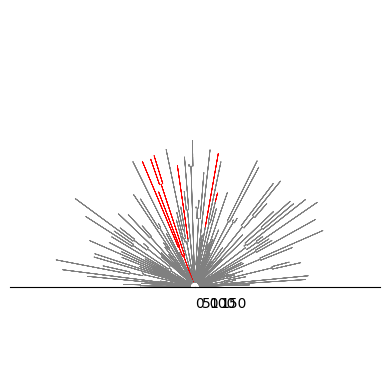

teeplots/2025-05-17-vanilla-treeviz/trt_name=sben1-1x-gdel1-1x+viz=draw-biopyhlo-vertical+ext=.pdf
teeplots/2025-05-17-vanilla-treeviz/trt_name=sben1-1x-gdel1-1x+viz=draw-biopyhlo-vertical+ext=.png


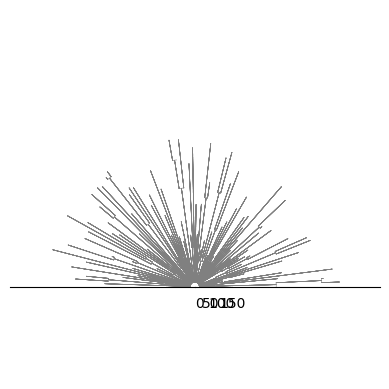

teeplots/2025-05-17-vanilla-treeviz/trt_name=sneu-gneu+viz=draw-biopyhlo-vertical+ext=.pdf
teeplots/2025-05-17-vanilla-treeviz/trt_name=sneu-gneu+viz=draw-biopyhlo-vertical+ext=.png


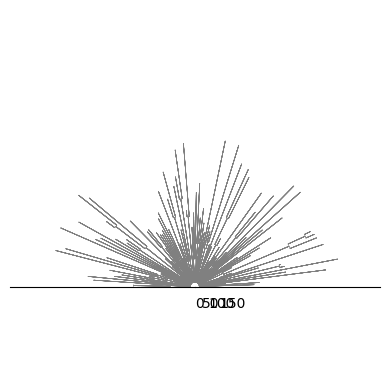

teeplots/2025-05-17-vanilla-treeviz/trt_name=sben2x-gneu+viz=draw-biopyhlo-vertical+ext=.pdf
teeplots/2025-05-17-vanilla-treeviz/trt_name=sben2x-gneu+viz=draw-biopyhlo-vertical+ext=.png


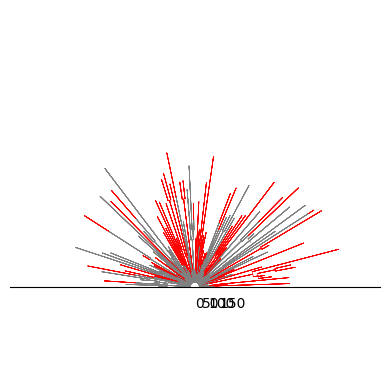

teeplots/2025-05-17-vanilla-treeviz/trt_name=sben1-3x-gdel1-3x+viz=draw-biopyhlo-vertical+ext=.pdf
teeplots/2025-05-17-vanilla-treeviz/trt_name=sben1-3x-gdel1-3x+viz=draw-biopyhlo-vertical+ext=.png


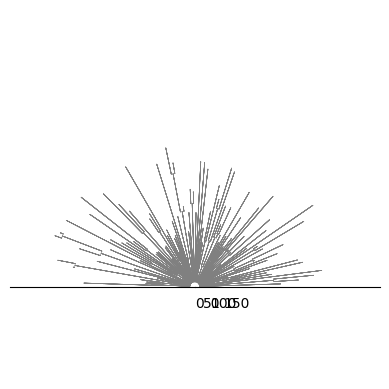

teeplots/2025-05-17-vanilla-treeviz/trt_name=sben1-1x-gneu+viz=draw-biopyhlo-vertical+ext=.pdf
teeplots/2025-05-17-vanilla-treeviz/trt_name=sben1-1x-gneu+viz=draw-biopyhlo-vertical+ext=.png


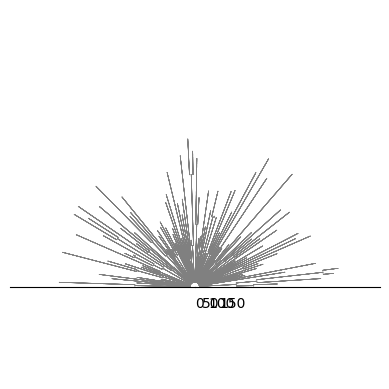

teeplots/2025-05-17-vanilla-treeviz/trt_name=sben2x-gdel2x+viz=draw-biopyhlo-vertical+ext=.pdf
teeplots/2025-05-17-vanilla-treeviz/trt_name=sben2x-gdel2x+viz=draw-biopyhlo-vertical+ext=.png


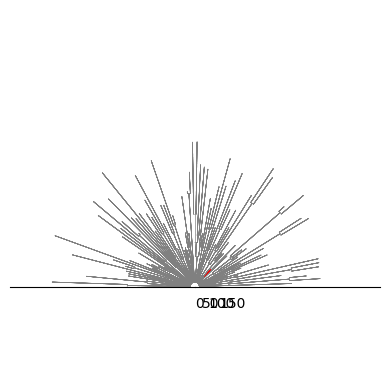

In [9]:
for (trt_name,), group in fil.group_by("trt_name"):
    display(HTML(f"<h1>{trt_name}</h1>"))

    phylo_df = group.to_pandas()
    phylo_df = hstrat_aux.alifestd_mask_descendants_asexual(
        phylo_df,
        ancestor_mask=phylo_df["is_focal_defmut"],
    )

    phylo_df["extant"] = (phylo_df["origin_time"] > 100) | (
        phylo_df["alifestd_mask_descendants_asexual"]
    )
    phylo_df = hstrat_aux.alifestd_prune_extinct_lineages_asexual(phylo_df)

    phylo_df = hstrat_aux.alifestd_downsample_tips_asexual(phylo_df, 100)

    newick = hstrat_aux.alifestd_as_newick_asexual(
        phylo_df,
        taxon_label="alifestd_mask_descendants_asexual",
    )

    tree = BioPhylo.read(io.StringIO(newick), "newick")

    for clade in tree.find_clades():
        clade.color = "red" if clade.name == "True" else "gray"
        clade.width = 0.3

    with tp.teed(
        draw_biopyhlo_vertical,
        tree,
        label_func=lambda clade: "",
        interp_unit=0.2,
        polar=True,
        y_scale=math.pi,
        do_show=False,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={
            "trt_name": slugify(trt_name),
        },
    ) as ax:
        ax.set_xlim(0, math.pi)
        ax.set_ylim(-20, None)
        ax.set_yticks([0, 50, 100, 150])
        ax.grid(False)
        ax.get_xaxis().set_visible(False)
        ax.get_xaxis().set_visible(False)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.spines["polar"].set_visible(False)
        ax.spines["start"].set_visible(False)
        ax.spines["end"].set_visible(False)
        ax.spines["inner"].set_visible(False)

        disable_ax_clip(ax)
